In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

from google.colab import files
uploaded = files.upload()

pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")
tests = pd.read_csv("tests.csv")

Saving combats.csv to combats (2).csv
Saving pokemon.csv to pokemon (1).csv
Saving tests.csv to tests (1).csv


In [8]:
print("POKEMON DATASET")
display(pokemon.head())
print(pokemon.shape)
print(pokemon.info())

print("\nCOMBATS DATASET")
display(combats.head())
print(combats.shape)
print(combats.info())

print("\nTESTS DATASET")
display(tests.head())
print(tests.shape)
print(tests.info())

POKEMON DATASET


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


(800, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB
None

COMBATS DATASET


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


(50000, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB
None

TESTS DATASET


,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


(10000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   10000 non-null  int64
 1   Second_pokemon  10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB
None


In [9]:
print("Missing values in pokemon:")
print(pokemon.isnull().sum())

print("\nMissing values in combats:")
print(combats.isnull().sum())

print("\nRows with missing Name:")
display(pokemon[pokemon["Name"].isnull()])

Missing values in pokemon:
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Missing values in combats:
First_pokemon     0
Second_pokemon    0
Winner            0
dtype: int64

Rows with missing Name:


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False


In [10]:
pokemon.loc[pokemon["#"] == 63, "Name"] = "Primeape"
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

print("Missing values after cleaning:")
print(pokemon.isnull().sum())

Missing values after cleaning:
#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


The dataset required minimal cleaning, which indicates relatively high data quality. The only necessary adjustments were filling a missing Pokémon name and handling missing values in the secondary type column. After this step, the dataset became consistent and ready for analysis without introducing bias from complex imputations.

In [11]:
all_battles = pd.concat([combats["First_pokemon"], combats["Second_pokemon"]])

battle_counts = all_battles.value_counts().sort_index()

win_counts = combats["Winner"].value_counts().sort_index()

battle_stats = pd.DataFrame({
    "#": battle_counts.index,
    "total_battles": battle_counts.values
})

battle_stats["wins"] = battle_stats["#"].map(win_counts).fillna(0).astype(int)

battle_stats["win_percentage"] = battle_stats["wins"] / battle_stats["total_battles"]

display(battle_stats.head())
print(battle_stats.shape)

,#,total_battles,wins,win_percentage
0,1,133,37,0.278195
1,2,121,46,0.380165
2,3,132,89,0.674242
3,4,125,70,0.560000
4,5,112,55,0.491071


(784, 4)


In [12]:
df = pokemon.merge(battle_stats, on="#", how="left")

df["total_battles"] = df["total_battles"].fillna(0)
df["wins"] = df["wins"].fillna(0)
df["win_percentage"] = df["win_percentage"].fillna(0)

display(df.head())
print(df.shape)

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,total_battles,wins,win_percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,0.278195
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,0.380165
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,0.674242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,0.560000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,0.491071


(800, 15)


The addition of total_stats provides a simplified representation of overall strength. While individual stats capture specific abilities, their combination better reflects general combat potential. This feature is expected to play a significant role in predicting win percentage.

In [13]:
df["total_stats"] = (
    df["HP"] +
    df["Attack"] +
    df["Defense"] +
    df["Sp. Atk"] +
    df["Sp. Def"] +
    df["Speed"]
)

display(df[["Name", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "total_stats", "win_percentage"]].head())

,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,total_stats,win_percentage
0,Bulbasaur,45,49,49,65,65,45,318,0.278195
1,Ivysaur,60,62,63,80,80,60,405,0.380165
2,Venusaur,80,82,83,100,100,80,525,0.674242
3,Mega Venusaur,80,100,123,122,120,80,625,0.560000
4,Charmander,39,52,43,60,50,65,309,0.491071


The original data does not directly measure performance, so a new variable — win percentage — was created. This transformation converts raw battle records into a meaningful metric that reflects overall effectiveness. It allows us to shift from analyzing individual battles to evaluating each long-term performance.
The addition of total_stats provides a simplified representation of overall strength. While individual stats capture specific abilities, their combination better reflects general combat potential. This feature is expected to play a significant role in predicting win percentage.

In [14]:
display(df.describe())

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,total_battles,wins,win_percentage,total_stats
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375,125.000000,62.500000,0.490881,435.10250
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129,21.130147,33.852141,0.262442,119.96304
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000,0.000000,0.000000,0.000000,180.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000,120.000000,34.750000,0.274194,330.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000,127.000000,61.000000,0.479281,450.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000,135.000000,90.000000,0.709178,515.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000,164.000000,152.000000,0.984496,780.00000


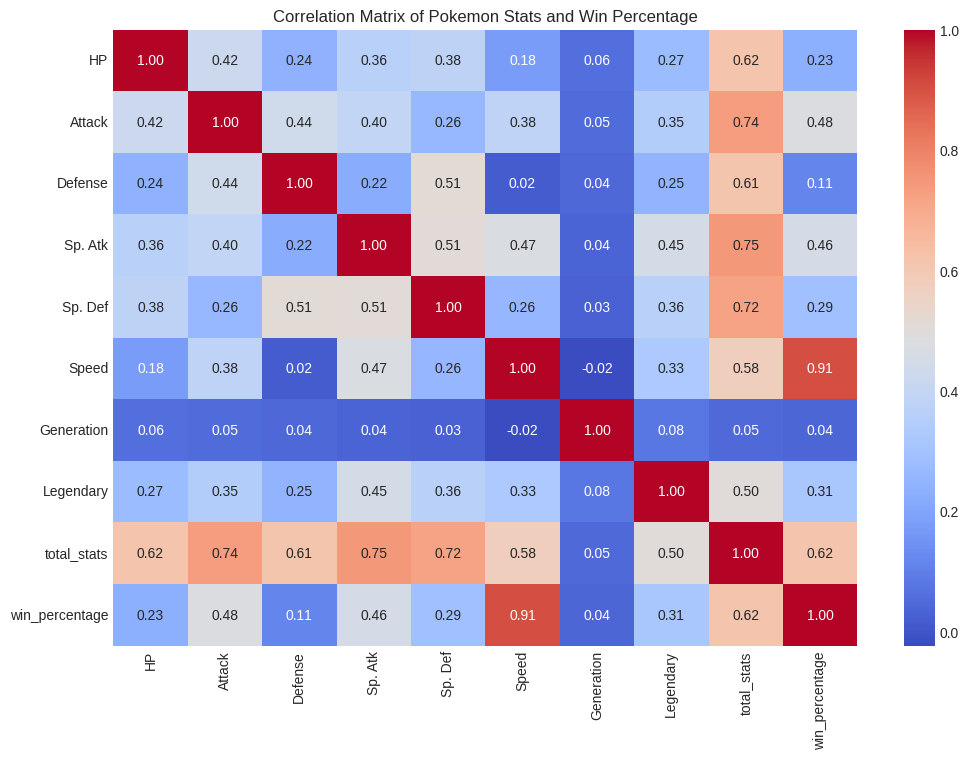

In [15]:
corr_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation", "Legendary", "total_stats", "win_percentage"]

# Legendary пока bool, переведём во временный int для корреляции
df_corr = df.copy()
df_corr["Legendary"] = df_corr["Legendary"].astype(int)

corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Pokemon Stats and Win Percentage")
plt.show()

The correlation matrix shows that battle success is influenced more by speed and offensive capabilities than by defensive attributes. No single variable dominates, suggesting that performance depends on multiple interacting factors. The moderate correlations indicate that relationships are not purely linear.

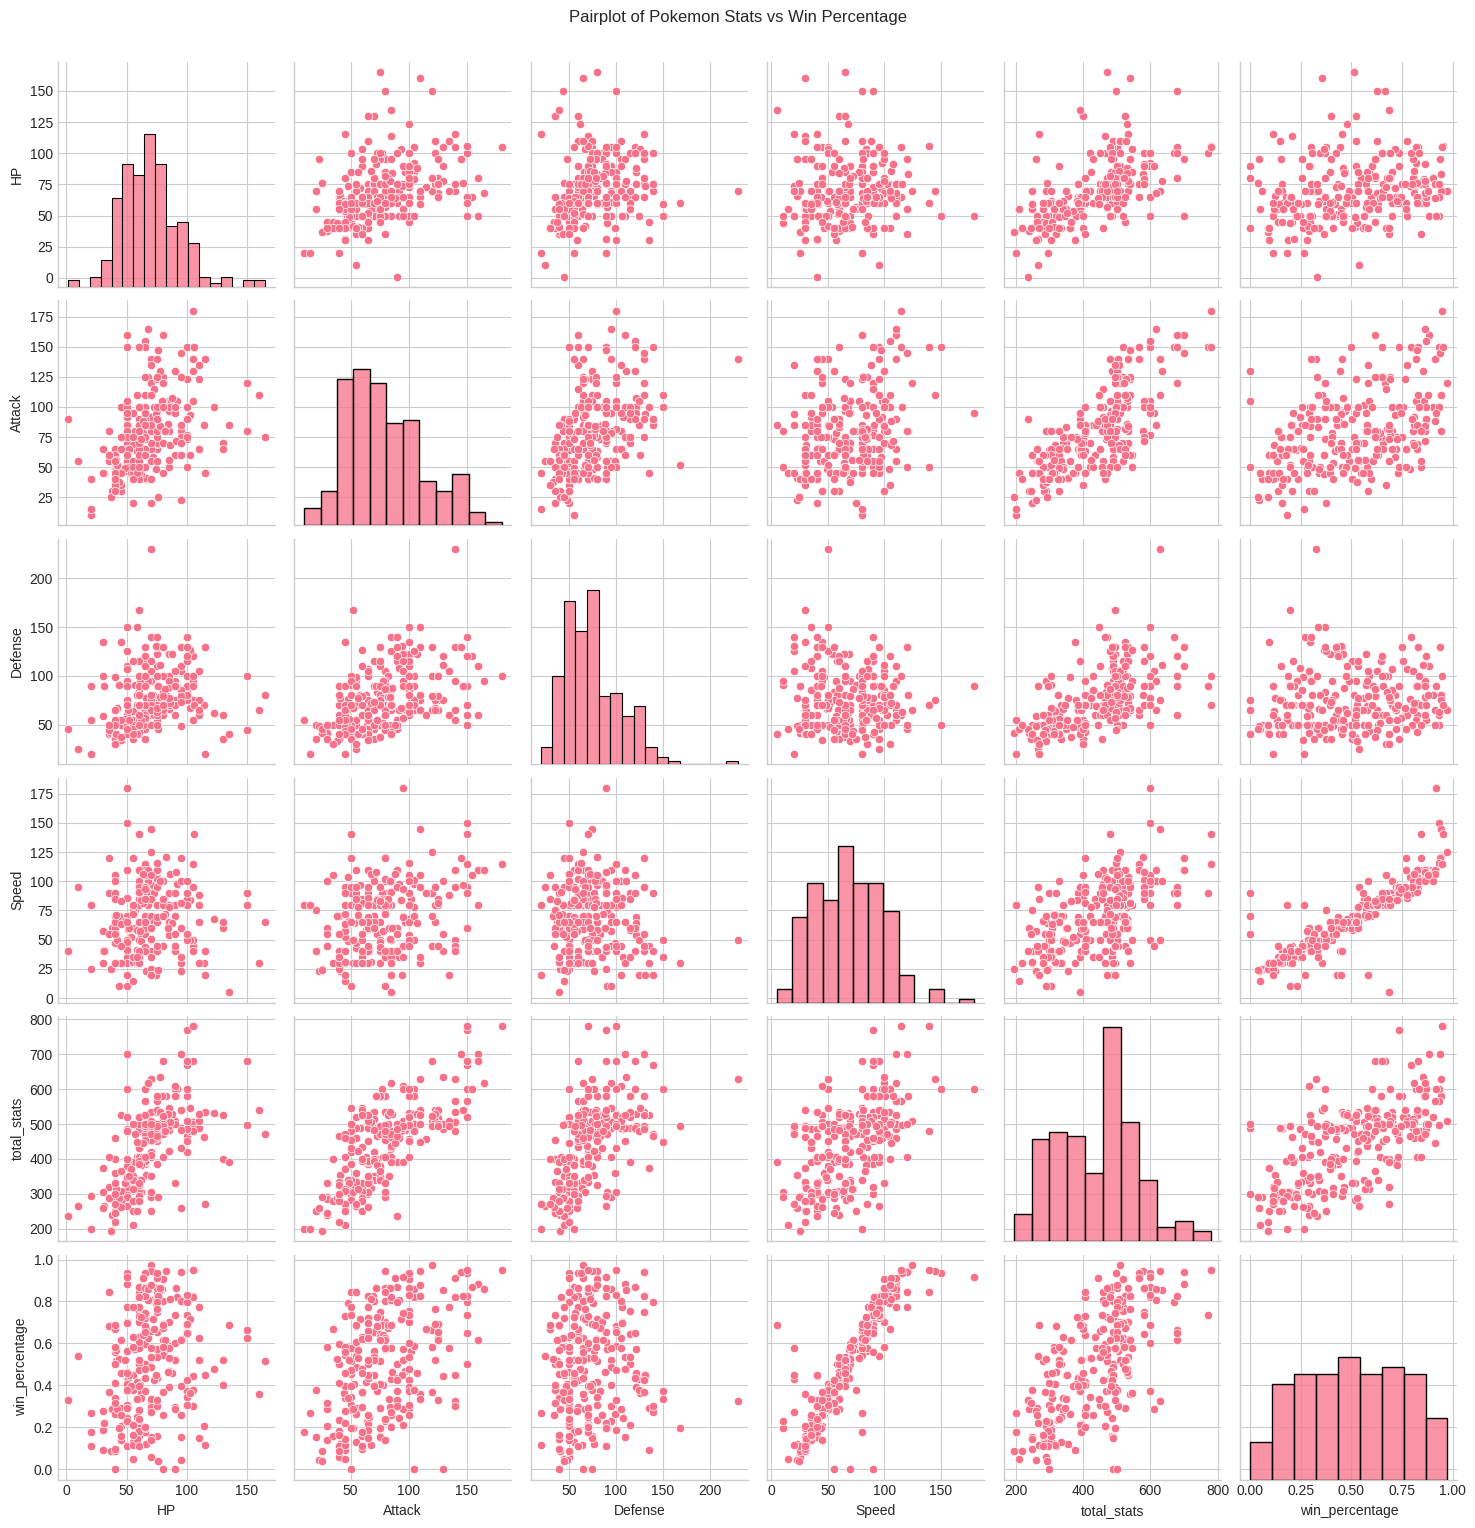

In [16]:
pairplot_cols = ["HP", "Attack", "Defense", "Speed", "total_stats", "win_percentage"]

sample_df = df[pairplot_cols].sample(min(250, len(df)), random_state=42)

sns.pairplot(sample_df)
plt.suptitle("Pairplot of Pokemon Stats vs Win Percentage", y=1.02)
plt.show()

Visual exploration confirms that the relationship between features and win percentage is complex and noisy. There is no clear linear pattern, which suggests that simple models may struggle. This reinforces the need for more flexible, non-linear approaches.

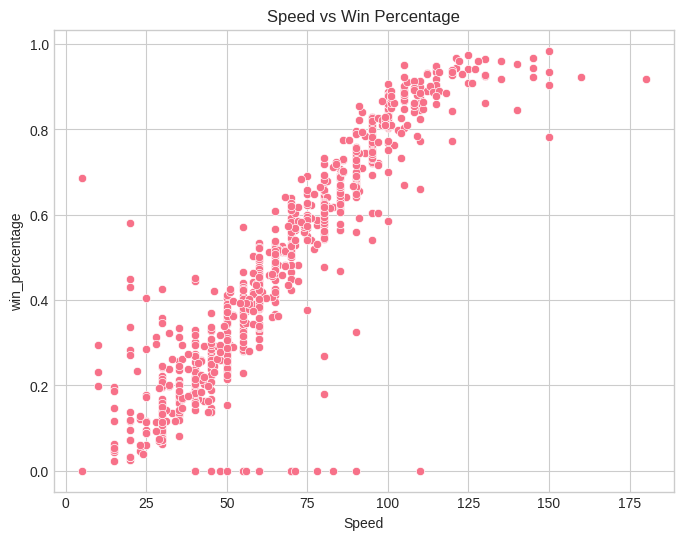

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Speed", y="win_percentage")
plt.title("Speed vs Win Percentage")
plt.show()

Speed appears to be one of the most influential attributes. Faster Pokémon generally achieve higher win rates, likely due to their ability to act first in battles. Variation in outcomes shows that speed alone does not determine success.

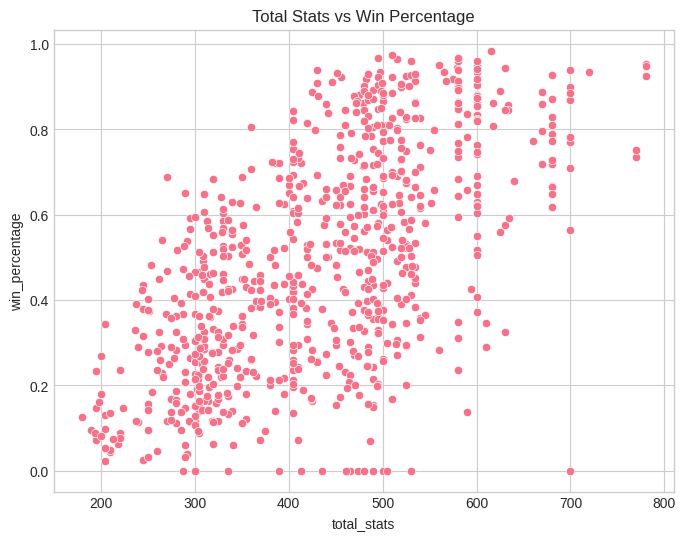

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="total_stats", y="win_percentage")
plt.title("Total Stats vs Win Percentage")
plt.show()

Total stats are positively associated with win percentage, indicating that stronger tend to perform better.

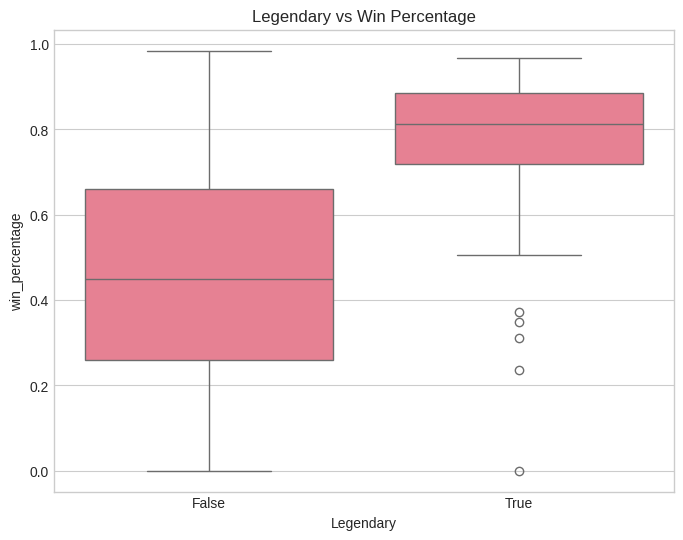

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Legendary", y="win_percentage")
plt.title("Legendary vs Win Percentage")
plt.show()

Legendary tend to outperform regular ones, which is consistent with their higher base stats. Overlap between distributions shows that strong Non-Legendary can still compete effectively, meaning Legendary status is helpful, but not decisive.

In [24]:
top10 = (df[df["total_battles"] >= 10].sort_values("win_percentage", ascending=False).head(10))
display(top10[["#", "Name", "Type 1", "Type 2", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "total_stats", "total_battles", "wins", "win_percentage"]])

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,total_stats,total_battles,wins,win_percentage
154,155,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,615,129.0,127.0,0.984496
512,513,Weavile,Dark,Ice,70,120,65,45,85,125,510,119.0,116.0,0.974790
703,704,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,580,125.0,121.0,0.968000
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,495,119.0,115.0,0.966387
153,154,Aerodactyl,Rock,Flying,80,105,65,60,75,130,515,141.0,136.0,0.964539
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,580,129.0,124.0,0.961240
726,727,Greninja,Water,Dark,72,95,67,103,71,122,530,127.0,122.0,0.960630
716,717,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,600,123.0,118.0,0.959350
164,165,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,780,125.0,119.0,0.952000
349,350,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,560,120.0,114.0,0.950000


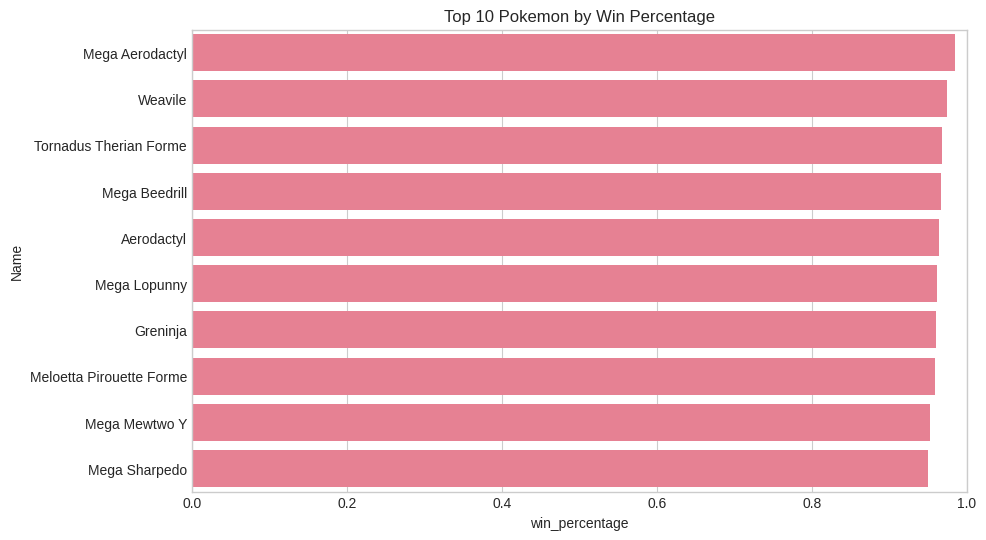

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="win_percentage", y="Name")
plt.title("Top 10 Pokemon by Win Percentage")
plt.xlim(0, 1)
plt.show()

The highest-performing combine high speed with strong offensive attributes. Their success is not random but aligned with their characteristics. Applying a minimum battle threshold was necessary to avoid misleading results caused by small sample sizes.

In [26]:
ml_df = df.copy()

ml_df["Legendary"] = ml_df["Legendary"].astype(int)
ml_df = pd.get_dummies(ml_df, columns=["Type 1", "Type 2"], drop_first=True)

drop_cols = ["#", "Name", "win_percentage", "wins", "total_battles"]
X = ml_df.drop(columns=drop_cols)
y = ml_df["win_percentage"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (800, 44)
y shape: (800,)


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,total_stats,Type 1_Dark,...,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_None,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
0,45,49,49,65,65,45,1,0,318,False,...,False,False,False,False,False,True,False,False,False,False
1,60,62,63,80,80,60,1,0,405,False,...,False,False,False,False,False,True,False,False,False,False
2,80,82,83,100,100,80,1,0,525,False,...,False,False,False,False,False,True,False,False,False,False
3,80,100,123,122,120,80,1,0,625,False,...,False,False,False,False,False,True,False,False,False,False
4,39,52,43,60,50,65,1,0,309,False,...,False,False,False,True,False,False,False,False,False,False


After preprocessing, the dataset is fully numerical and suitable for regression models. Encoding categorical variables allows the model to capture type-related effects. The problem is now clearly defined as predicting a continuous target: win percentage.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (640, 44) (640,)
Test shape: (160, 44) (160,)


In [28]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 0.06142367914828719


Linear Regression provides a baseline but struggles to capture the complexity of the data. Its performance suggests that the relationship between Pokemon attributes and success is not purely linear.

In [29]:
# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=None,n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regressor MAE:", rf_mae)

Random Forest Regressor MAE: 0.05524891528932955


Random Forest significantly improves performance by capturing non-linear interactions between features. This indicates that battle outcomes depend on complex combinations of attributes rather than simple additive effects.

In [30]:
# Gradient Boosting
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)
gbr_mae = mean_absolute_error(y_test, gbr_pred)

print("Gradient Boosting Regressor MAE:", gbr_mae)

Gradient Boosting Regressor MAE: 0.05071637101712051


Gradient Boosting refines predictions by focusing on errors made by previous models. Its performance demonstrates that iterative learning can further improve accuracy, making it a strong alternative to Random Forest.

In [31]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor", "Gradient Boosting Regressor"],
    "MAE": [lr_mae, rf_mae, gbr_mae]
}).sort_values("MAE")

display(results)

,Model,MAE
2,Gradient Boosting Regressor,0.050716
1,Random Forest Regressor,0.055249
0,Linear Regression,0.061424


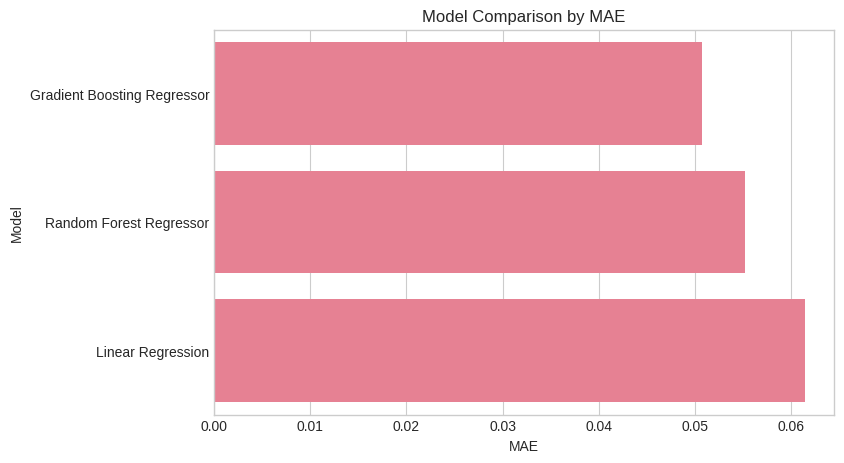

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="MAE", y="Model")
plt.title("Model Comparison by MAE")
plt.show()

Comparing models using MAE shows that tree-based methods outperform linear models. This confirms that non-linear relationships are important in predicting win percentage. The best model is the one with the lowest prediction error.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

,Feature,Importance
5,Speed,0.880641
1,Attack,0.035223
4,Sp. Def,0.015684
0,HP,0.010578
3,Sp. Atk,0.010411
8,total_stats,0.010391
2,Defense,0.007728
6,Generation,0.004212
33,Type 2_Ghost,0.003252
17,Type 1_Grass,0.002579


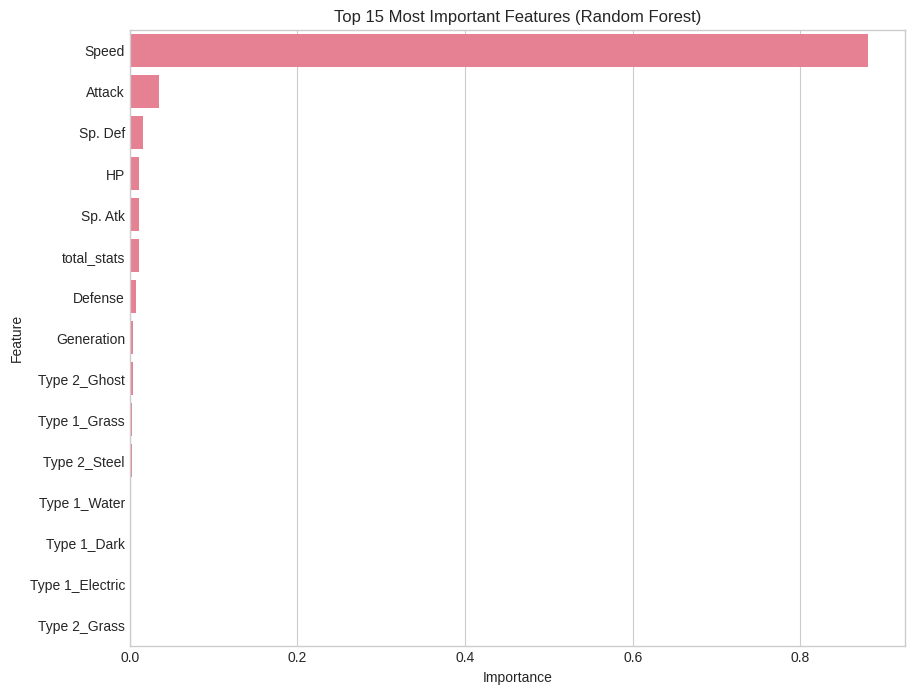

In [34]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.show()

Feature importance analysis highlights speed, attack and total stats as key drivers of performance. These results align with earlier observations from exploratory analysis, reinforcing the consistency of findings across methods.

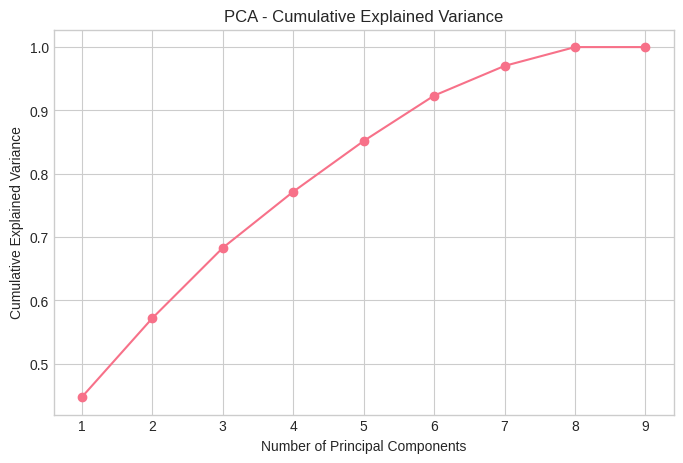

In [35]:
numeric_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation", "Legendary", "total_stats"]

pca_df = df.copy()
pca_df["Legendary"] = pca_df["Legendary"].astype(int)

X_numeric = pca_df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)
plt.show()

PCA shows that variability can be explained with fewer components, indicating redundancy among features. However, dimensionality reduction is not essential for predictive performance in this case and is mainly useful for exploration.

**CONCLUSION:** The analysis demonstrates that Pokémon battle success is predictable from their base attributes. Performance is driven by a combination of speed and offensive strength rather than any single factor. Non-linear models provide the most accurate predictions, confirming the complexity of the relationships in the data.